### Step 1: Data Preprocessing
Handle missing values and duplicates.


Normalize or scale numerical features.


Encode categorical features like Location and Property_Type.


Create new features like Price per Sqft, Amenity Density Score, etc.
Create a binary label "Good Investment" based on domain rules (e.g., appreciation rate > threshold).



In [1]:
import pandas as pd

# Load your CSV file (replace 'your_file.csv' with your actual file path)
# C:\Users\PRANAV CHATURVEDI\Downloads\guvi 28 march\real estate investment advisor
df = pd.read_csv('india_housing_prices.csv')

# Columns A to W correspond to the first 23 columns (indices 0 to 22)
df_subset = df.iloc[:, 0:23]

# Display the names of the selected columns to verify
print("Selected columns:")
print(list(df_subset.columns))


Selected columns:
['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']


In [2]:
# 1. Get the total count of missing values per column
missing_counts = df_subset.isnull().sum()

# 2. Filter to show only columns that actually have missing values
missing_summary = missing_counts[missing_counts > 0]

print("--- Missing Values Summary ---")
if not missing_summary.empty:
    print(missing_summary)
else:
    print("No missing values found in columns A to W.")


--- Missing Values Summary ---
No missing values found in columns A to W.


In [3]:
# 1. Count total duplicate rows across these specific columns
total_duplicates = df_subset.duplicated().sum()

# 2. Extract and view the actual duplicate rows (keeping all occurrences)
duplicate_rows = df_subset[df_subset.duplicated(keep=False)]

print("--- Duplicates Summary ---")
print(f"Total duplicate rows found: {total_duplicates}\n")

if total_duplicates > 0:
    print("Preview of duplicate rows:")
    display(duplicate_rows.head(10))  # Shows the first 10 duplicate rows in Jupyter


--- Duplicates Summary ---
Total duplicate rows found: 0



### Cell 1: Identify and Separate Numerical Features

In [4]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Automatically detect which columns in your subset are numeric
numeric_cols = df_subset.select_dtypes(include=['number']).columns

print("Numerical columns identified for scaling:")
print(list(numeric_cols))


Numerical columns identified for scaling:
['ID', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']


In [5]:
import pandas as pd
import json

csv_path = r"c:\Users\PRANAV CHATURVEDI\Downloads\guvi 28 march\real estate investment advisor\india_housing_prices.csv"

# Read only first 50000 rows for speed, or read fully if needed
df = pd.read_csv(csv_path)

print("Columns:")
print(df.columns.tolist())

numerical_cols = ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']

print("\nMissing values in numerical columns:")
print(df[numerical_cols].isnull().sum().to_dict())

print("\nDescriptive statistics:")
desc = df[numerical_cols].describe()
print(desc.to_string())

print("\nSkewness:")
print(df[numerical_cols].skew().to_dict())



Columns:
['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility', 'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']

Missing values in numerical columns:
{'BHK': 0, 'Size_in_SqFt': 0, 'Price_in_Lakhs': 0, 'Price_per_SqFt': 0, 'Year_Built': 0, 'Floor_No': 0, 'Total_Floors': 0, 'Age_of_Property': 0, 'Nearby_Schools': 0, 'Nearby_Hospitals': 0}

Descriptive statistics:
                 BHK   Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt     Year_Built       Floor_No   Total_Floors  Age_of_Property  Nearby_Schools  Nearby_Hospitals
count  250000.000000  250000.000000   250000.000000   250000.000000  250000.000000  250000.000000  250000.000000    250000.000000   250000.000000     250000.000000
mean        2.999396    2749.813216      254.586854      

In [6]:
import pandas as pd
import numpy as np

csv_path = r"c:\Users\PRANAV CHATURVEDI\Downloads\guvi 28 march\real estate investment advisor\india_housing_prices.csv"
df = pd.read_csv(csv_path)

col = df['Price_per_SqFt']
print("Original skewness:", col.skew())
print("Log1p skewness:", np.log1p(col).skew())
# Since it contains 0 or very small values, let's see min value:
print("Min value:", col.min())
# If min is 0, let's see how many are 0:
print("Count of 0 values:", (col == 0).sum())
print("Log skewness (excluding 0 or adding small constant):")
print("Log(col + 1e-4) skewness:", np.log(col + 1e-4).skew())
print("Log(col + 1e-2) skewness:", np.log(col + 1e-2).skew())
print("Log(col) for positive values skewness:", np.log(col[col > 0]).skew())

# Yeo-Johnson PowerTransformer
from sklearn.preprocessing import PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
transformed = pt.fit_transform(col.values.reshape(-1, 1))
print("Yeo-Johnson skewness:", pd.Series(transformed.flatten()).skew())



Original skewness: 2.318667943458113
Log1p skewness: 1.8702861884400896
Min value: 0.0
Count of 0 values: 2534
Log skewness (excluding 0 or adding small constant):
Log(col + 1e-4) skewness: -1.947689975186831
Log(col + 1e-2) skewness: -0.0880435628716227
Log(col) for positive values skewness: -0.28793371920701666


Yeo-Johnson skewness: 0.23746987275406387


### This block handles all aspects of scaling:

Removes ID from scaling by setting it as the DataFrame index.
Transforms Price_per_SqFt using the Yeo-Johnson method to eliminate its high positive skewness (2.32 $\rightarrow$ 0.23) and handle the zero values.
Applies MinMaxScaler to scale all numerical features to the range $[0, 1]$.


#### Why this works:
##### Yeo-Johnson Transformer: Since 2,534 properties have 0.0 for Price_per_SqFt, standard log scaling (np.log) fails. Yeo-Johnson gracefully handles zeros and reduces skewness from 2.32 to 0.23.
##### MinMaxScaler: Excellent choice here because your columns (e.g., BHK, floor numbers, age) have fixed limits and uniform distributions without extreme outliers.

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

# 1. Create a copy of the subset to avoid SettingWithCopy warnings
df_scaled = df_subset.copy()

# 2. Set 'ID' as the index so it is excluded from scaling but preserved
df_scaled.set_index('ID', inplace=True)

# 3. Handle the highly skewed 'Price_per_SqFt' using Yeo-Johnson Power Transform
pt = PowerTransformer(method='yeo-johnson')
df_scaled['Price_per_SqFt'] = pt.fit_transform(df_scaled[['Price_per_SqFt']])

# 4. List all numerical columns (including the transformed 'Price_per_SqFt')
cols_to_scale = [
    'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 
    'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 
    'Nearby_Schools', 'Nearby_Hospitals'
]

# 5. Apply Min-Max Scaling to scale everything to the [0, 1] range
scaler = MinMaxScaler()
df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

# 6. Verify the scale bounds (Min should be 0, Max should be 1) and display preview
print("Scaled Min bounds:\n", df_scaled[cols_to_scale].min())
print("\nScaled Max bounds:\n", df_scaled[cols_to_scale].max())
print("\nPreview of scaled features:")
df_scaled[cols_to_scale].head()


Scaled Min bounds:
 BHK                 0.0
Size_in_SqFt        0.0
Price_in_Lakhs      0.0
Price_per_SqFt      0.0
Year_Built          0.0
Floor_No            0.0
Total_Floors        0.0
Age_of_Property     0.0
Nearby_Schools      0.0
Nearby_Hospitals    0.0
dtype: float64

Scaled Max bounds:
 BHK                 1.0
Size_in_SqFt        1.0
Price_in_Lakhs      1.0
Price_per_SqFt      1.0
Year_Built          1.0
Floor_No            1.0
Total_Floors        1.0
Age_of_Property     1.0
Nearby_Schools      1.0
Nearby_Hospitals    1.0
dtype: float64

Preview of scaled features:


,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
ID,,,,,,,,,,
1,0.00,0.942222,0.979102,0.471236,0.000000,0.733333,0.000000,1.000000,1.000000,0.222222
2,0.50,0.414222,0.378612,0.401922,0.545455,0.700000,0.655172,0.454545,0.777778,0.000000
3,0.25,0.698222,0.354673,0.277790,0.212121,0.633333,0.896552,0.787879,0.888889,0.777778
4,0.25,0.498000,0.592429,0.502458,0.030303,0.700000,0.862069,0.969697,0.444444,0.666667
5,0.75,0.960667,0.352857,0.230104,0.363636,0.100000,0.034483,0.636364,0.333333,0.888889


### 1. Classification & Scaling Strategy
#### A. Ordinal Columns (Have a natural order)
Columns: Public_Transport_Accessibility (Low $\rightarrow$ Medium $\rightarrow$ High), Furnished_Status (Unfurnished $\rightarrow$ Semi-furnished $\rightarrow$ Furnished).
Encoding: Map them to ordered integers (e.g., $0, 1, 2$).
Scaling Requirement: Yes, they should be scaled. Once encoded as $0, 1, 2$, we apply MinMaxScaler so they map to $0.0, 0.5, 1.0$ respectively, placing them on the exact same scale as the other features.
#### B. Binary Columns (Only two possible states)
Columns: Parking_Space (Yes/No), Security (Yes/No), Availability_Status (Ready_to_Move/Under_Construction).
Encoding: Map directly to $0$ and $1$ (e.g., No $\rightarrow$ $0$, Yes $\rightarrow$ $1$).
Scaling Requirement: No extra scaling needed. Since their range is already exactly $[0, 1]$, they are natively scaled!
#### C. Nominal Columns (No natural order)
Columns: Facing (West, North, South, East), Owner_Type (Owner, Builder, Broker), Property_Type (Apartment, Independent House, Villa).
Encoding: One-Hot Encoding (creating dummy binary columns for each value, e.g., Facing_East, Facing_West).
Scaling Requirement: No extra scaling needed. One-hot encoded columns only contain $0$ or $1$, which means they are already scaled.
#### D. Multi-Label String Columns
Columns: Amenities (contains lists like "Playground, Gym, Garden").
Encoding Option 1 (Binary Flag per Amenity): Split the list and create individual binary columns (e.g., has_Gym $\rightarrow$ $0$ or $1$). These are natively scaled.
Encoding Option 2 (Amenity Count): Count how many amenities a property has (e.g., $3, 5$). This creates a continuous count feature that requires scaling (e.g., mapped to $[0, 1]$). We will implement both approaches in the code.

In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

# 1. Copy the subset DataFrame
df_encoded = df_subset.copy()
df_encoded.set_index('ID', inplace=True)

# 2. Treat the skewed feature 'Price_per_SqFt' first
pt = PowerTransformer(method='yeo-johnson')
df_encoded['Price_per_SqFt'] = pt.fit_transform(df_encoded[['Price_per_SqFt']])

# --- ENCODING CATEGORICAL FEATURES ---

# A. Ordinal Encoding
transport_map = {'Low': 0, 'Medium': 1, 'High': 2}
furnished_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Furnished': 2}
df_encoded['Public_Transport_Accessibility'] = df_encoded['Public_Transport_Accessibility'].map(transport_map)
df_encoded['Furnished_Status'] = df_encoded['Furnished_Status'].map(furnished_map)

# B. Binary Encoding
binary_map = {'No': 0, 'Yes': 1}
availability_map = {'Under_Construction': 0, 'Ready_to_Move': 1}
df_encoded['Parking_Space'] = df_encoded['Parking_Space'].map(binary_map)
df_encoded['Security'] = df_encoded['Security'].map(binary_map)
df_encoded['Availability_Status'] = df_encoded['Availability_Status'].map(availability_map)

# C. Multi-Label Encoding for 'Amenities'
# - Create a count of total amenities (requires scaling)
df_encoded['Amenity_Count'] = df_encoded['Amenities'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) else 0)
# - Create binary dummy variables for each individual amenity (already scaled as 0/1)
amenity_dummies = df_encoded['Amenities'].str.get_dummies(sep=', ')
# Prefix the columns for clarity and join them back
amenity_dummies = amenity_dummies.add_prefix('Amenity_')
df_encoded = df_encoded.join(amenity_dummies).drop(columns=['Amenities'])

# D. One-Hot Encoding for Nominal Columns
df_encoded = pd.get_dummies(df_encoded, columns=['Facing', 'Owner_Type', 'Property_Type'], dtype=int)


# --- SCALING ---

# All numerical features that need MinMax Scaling
cols_to_scale = [
    'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 
    'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 
    'Nearby_Schools', 'Nearby_Hospitals',
    'Public_Transport_Accessibility', 'Furnished_Status', 'Amenity_Count'
]

scaler = MinMaxScaler()
df_encoded[cols_to_scale] = scaler.fit_transform(df_encoded[cols_to_scale])

# Preview the final encoded and scaled dataset
print("Shape of dataset after encoding and scaling:", df_encoded.shape)
print("\nFirst 3 rows of processed dataset:")
display(df_encoded.head(3))


Shape of dataset after encoding and scaling: (250000, 34)

First 3 rows of processed dataset:


,State,City,Locality,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Facing_East,Facing_North,Facing_South,Facing_West,Owner_Type_Broker,Owner_Type_Builder,Owner_Type_Owner,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa
ID,,,,,,,,,,,,,,,,,,,,,
1,Tamil Nadu,Chennai,Locality_84,0.00,0.942222,0.979102,0.471236,0.000000,1.0,0.733333,...,0,0,0,1,0,0,1,1,0,0
2,Maharashtra,Pune,Locality_490,0.50,0.414222,0.378612,0.401922,0.545455,0.0,0.700000,...,0,1,0,0,0,1,0,0,1,0
3,Punjab,Ludhiana,Locality_167,0.25,0.698222,0.354673,0.277790,0.212121,0.5,0.633333,...,0,0,1,0,1,0,0,1,0,0


In [9]:
import pandas as pd

csv_path = r"c:\Users\PRANAV CHATURVEDI\Downloads\guvi 28 march\real estate investment advisor\india_housing_prices.csv"
df = pd.read_csv(csv_path)

print("Unique values in Furnished_Status:", df['Furnished_Status'].unique())
print("Unique values in Public_Transport_Accessibility:", df['Public_Transport_Accessibility'].unique())
print("Unique values in Parking_Space:", df['Parking_Space'].unique())
print("Unique values in Security:", df['Security'].unique())
print("Unique values in Facing:", df['Facing'].unique())
print("Unique values in Owner_Type:", df['Owner_Type'].unique())
print("Unique values in Availability_Status:", df['Availability_Status'].unique())
print("Unique values in Property_Type:", df['Property_Type'].unique())
# Sample amenities:
print("Sample Amenities:")
print(df['Amenities'].dropna().head(10).tolist())



Unique values in Furnished_Status: ['Furnished' 'Unfurnished' 'Semi-furnished']
Unique values in Public_Transport_Accessibility: ['High' 'Low' 'Medium']
Unique values in Parking_Space: ['No' 'Yes']
Unique values in Security: ['No' 'Yes']
Unique values in Facing: ['West' 'North' 'South' 'East']
Unique values in Owner_Type: ['Owner' 'Builder' 'Broker']
Unique values in Availability_Status: ['Ready_to_Move' 'Under_Construction']
Unique values in Property_Type: ['Apartment' 'Independent House' 'Villa']
Sample Amenities:
['Playground, Gym, Garden, Pool, Clubhouse', 'Playground, Clubhouse, Pool, Gym, Garden', 'Clubhouse, Pool, Playground, Gym', 'Playground, Clubhouse, Gym, Pool, Garden', 'Playground, Garden, Gym, Pool, Clubhouse', 'Playground, Clubhouse', 'Clubhouse, Garden, Playground', 'Gym, Pool, Clubhouse, Playground', 'Garden, Clubhouse, Playground', 'Clubhouse, Playground, Garden, Gym']


### The Professional Solution: The Scikit-Learn Pipeline
Instead of modifying the dataframe in place, the industry standard is to:

Keep the main DataFrame df unscaled and unencoded for EDA.
Build a Pipeline (using Scikit-Learn's ColumnTransformer) that holds the scaling and encoding instructions.
Pass the raw data to the pipeline. The pipeline scales the data internally during training, and you log the entire pipeline to MLflow.
When you deploy the model from MLflow, it will accept raw data (e.g., "Unfurnished", 2500 SqFt) and scale it automatically using the saved state!

Here is how you can write this in your notebook to keep your EDA clean and prepare for MLflow:

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, PowerTransformer
from sklearn.ensemble import RandomForestRegressor # or any other model

# 1. Keep df_subset completely RAW for your EDA:
# You can plot, group-by, and analyze df_subset directly!

# 2. Split your data into features (X) and target (y)
X = df_subset.drop(columns=['ID', 'Price_in_Lakhs']) # Target is Price
y = df_subset['Price_in_Lakhs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Define which columns get what treatment
numeric_uniform = ['BHK', 'Size_in_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 
                   'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']
numeric_skewed = ['Price_per_SqFt']
categorical_cols = ['State', 'City', 'Locality', 'Property_Type', 'Furnished_Status', 
                    'Public_Transport_Accessibility', 'Parking_Space', 'Security', 
                    'Amenities', 'Facing', 'Owner_Type', 'Availability_Status']

# 4. Create the preprocessor (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        # MinMaxScaler for symmetric numerical features
        ('num_uniform', MinMaxScaler(), numeric_uniform),
        
        # Yeo-Johnson for skewed features
        ('num_skewed', Pipeline([
            ('yeo', PowerTransformer(method='yeo-johnson')),
            ('scale', MinMaxScaler())
        ]), numeric_skewed),
        
        # OneHotEncoder for categoricals (handles encoding on-the-fly)
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# 5. Bundle preprocessing and the model in a Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# 6. Fit the pipeline (this fits the scalers and the model together)
model_pipeline.fit(X_train, y_train)

# Now, when you log with MLflow:
# mlflow.sklearn.log_model(model_pipeline, "model")
# MLflow will save both the scalers/encoders AND the model as a single artifact!


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num_uniform', MinMaxScaler(),
                                                  ['BHK', 'Size_in_SqFt',
                                                   'Year_Built', 'Floor_No',
                                                   'Total_Floors',
                                                   'Age_of_Property',
                                                   'Nearby_Schools',
                                                   'Nearby_Hospitals']),
                                                 ('num_skewed',
                                                  Pipeline(steps=[('yeo',
                                                                   PowerTransformer()),
                                                                  ('scale',
                                                                   MinMaxScaler())]),
                                                  ['Price_per_SqFt']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['State', 'City', 'Locality',
                                                   'Property_Type',
                                                   'Furnished_Status',
                                                   'Public_Transport_Accessibility',
                                                   'Parking_Space', 'Security',
                                                   'Amenities', 'Facing',
                                                   'Owner_Type',
                                                   'Availability_Status'])])),
                ('regressor',
                 RandomForestRegressor(n_jobs=-1, random_state=42))])

In [11]:
# 1. Drop duplicate records
df_clean = df_subset.drop_duplicates()

# 2. Check & impute missing values (numerical -> median, categorical -> mode)
for col in df_clean.select_dtypes(include=['number']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())
for col in df_clean.select_dtypes(exclude=['number']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 3. Feature Engineering:
# A. Calculate exact Price_per_SqFt (Lakhs per SqFt)
df_clean['Price_per_SqFt'] = df_clean['Price_in_Lakhs'] / df_clean['Size_in_SqFt']

# B. Amenity Count & Density Score (number of amenities / max typical typical count of 5)
df_clean['Amenity_Count'] = df_clean['Amenities'].apply(lambda x: len(str(x).split(',')) if pd.notnull(x) and x != '' else 0)
df_clean['Amenity_Density_Score'] = df_clean['Amenity_Count'] / 5.0

# C. Floor Ratio (vertical position in the building)
df_clean['Floor_Ratio'] = df_clean['Floor_No'] / df_clean['Total_Floors'].clip(lower=1)

print("Duplicates handled, missing values checked, and new features engineered!")


Duplicates handled, missing values checked, and new features engineered!


In [12]:
# Define target label based on domain rules
city_median_price = df_clean.groupby('City')['Price_per_SqFt'].transform('median')

df_clean['Good_Investment'] = (
    (df_clean['Price_per_SqFt'] < city_median_price) & 
    (df_clean['Amenity_Count'] >= 3) & 
    (df_clean['Nearby_Schools'] >= 5)
).astype(int)

print("Good Investment target label created!")
print(df_clean['Good_Investment'].value_counts())


Good Investment target label created!
Good_Investment
0    204868
1     45132
Name: count, dtype: int64


In [13]:
# A. Ordinal Encoding
transport_map = {'Low': 0, 'Medium': 1, 'High': 2}
furnished_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Furnished': 2}
df_clean['Public_Transport_Accessibility_Encoded'] = df_clean['Public_Transport_Accessibility'].map(transport_map)
df_clean['Furnished_Status_Encoded'] = df_clean['Furnished_Status'].map(furnished_map)

# B. Binary Mapping
binary_map = {'No': 0, 'Yes': 1}
availability_map = {'Under_Construction': 0, 'Ready_to_Move': 1}
df_clean['Parking_Space_Encoded'] = df_clean['Parking_Space'].map(binary_map)
df_clean['Security_Encoded'] = df_clean['Security'].map(binary_map)
df_clean['Availability_Status_Encoded'] = df_clean['Availability_Status'].map(availability_map)

# C. Split list of Amenities into dummy flag columns
amenity_dummies = df_clean['Amenities'].str.get_dummies(sep=', ').add_prefix('Amenity_')
df_processed = df_clean.join(amenity_dummies)

# D. One-Hot encoding for nominal features: Facing, Owner_Type, Property_Type
df_processed = pd.get_dummies(df_processed, columns=['Facing', 'Owner_Type', 'Property_Type'], dtype=int)

# E. Save clean, encoded, but unscaled dataset for clean EDA
df_processed.to_csv('india_housing_prices_clean.csv', index=False)
print("Saved encoded, unscaled dataset to 'india_housing_prices_clean.csv'")


Saved encoded, unscaled dataset to 'india_housing_prices_clean.csv'


 ### Normalize skewed columns, scale values, and save scaled sheet
Corrects the skewness of Price_per_SqFt with a PowerTransformer, uses MinMaxScaler on all numerical features to normalize ranges to $[0, 1]$, and saves the dataset for training/MLflow tracking.

In [14]:
from sklearn.preprocessing import MinMaxScaler, PowerTransformer

# 1. Transform skewed Price_per_SqFt feature
pt = PowerTransformer(method='yeo-johnson')
df_processed['Price_per_SqFt_Scaled'] = pt.fit_transform(df_processed[['Price_per_SqFt']])

# 2. Set aside ID (exclude from scaling by setting as index)
df_processed.set_index('ID', inplace=True)

# 3. Apply MinMaxScaler to numerical variables
cols_to_scale = [
    'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt_Scaled', 
    'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 
    'Nearby_Schools', 'Nearby_Hospitals', 'Furnished_Status_Encoded',
    'Public_Transport_Accessibility_Encoded', 'Amenity_Count', 
    'Amenity_Density_Score', 'Floor_Ratio'
]

scaler = MinMaxScaler()
df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])

# 4. Save scaled processed dataset for ML model training
df_processed.to_csv('india_housing_prices_scaled.csv', index=True)
print("Saved scaled processed dataset to 'india_housing_prices_scaled.csv'")
display(df_processed.head(3))


Saved scaled processed dataset to 'india_housing_prices_scaled.csv'


,State,City,Locality,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,...,Facing_North,Facing_South,Facing_West,Owner_Type_Broker,Owner_Type_Builder,Owner_Type_Owner,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa,Price_per_SqFt_Scaled
ID,,,,,,,,,,,,,,,,,,,,,
1,Tamil Nadu,Chennai,Locality_84,0.00,0.942222,0.979102,0.103325,0.000000,Furnished,0.733333,...,0,0,1,0,0,1,1,0,0,0.475761
2,Maharashtra,Pune,Locality_490,0.50,0.414222,0.378612,0.082707,0.545455,Unfurnished,0.700000,...,1,0,0,0,1,0,0,1,0,0.404762
3,Punjab,Ludhiana,Locality_167,0.25,0.698222,0.354673,0.050464,0.212121,Semi-furnished,0.633333,...,0,1,0,1,0,0,1,0,0,0.270805


### A Much Better Scaling & Normalization Strategy
To fix this and make your dataset premium for MLflow and model training, we can use three advanced techniques:

1. Use StandardScaler for continuous features (instead of MinMaxScaler)
Instead of clamping values between $0$ and $1$ (which forces the lowest value to be exactly $0$), StandardScaler centers the continuous features around their mean ($0$). Values below the mean become negative, and values above become positive. This spreads the data out naturally and avoids artificial clustering at 0.0.

2. Do NOT scale Binary / One-Hot encoded columns
One-hot columns (like Facing_West) and binary columns (like Security) are already bounded between 0 and 1. There is no reason to run them through a scaler. We should leave them as-is.

3. Use Target Encoding for high-cardinality features (Locality and City)
Instead of creating hundreds of columns filled with 0s for every single locality (One-Hot Encoding), we can use Target Encoding. This replaces each locality name with the average house price of that locality.

Example: If the average price in Locality_84 is 300 Lakhs, the string "Locality_84" is replaced by 300.0.
This keeps the data dense (no extra columns of zeros), retains the spatial/economic relationships of the neighborhoods, and is highly efficient for MLflow signatures.

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, PowerTransformer

# 1. Create a copy of the dataset
df_improved = df_subset.copy()
df_improved.set_index('ID', inplace=True)

# 2. Treat the skewed feature 'Price_per_SqFt' using Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
df_improved['Price_per_SqFt_Transformed'] = pt.fit_transform(df_improved[['Price_per_SqFt']])

# --- ENCODING ---

# A. Ordinal Map mapping (leave as integers, do not scale one-hot)
transport_map = {'Low': 0, 'Medium': 1, 'High': 2}
furnished_map = {'Unfurnished': 0, 'Semi-furnished': 1, 'Furnished': 2}
df_improved['Public_Transport_Accessibility'] = df_improved['Public_Transport_Accessibility'].map(transport_map)
df_improved['Furnished_Status'] = df_improved['Furnished_Status'].map(furnished_map)

# B. Binary Mapping (already naturally scaled between 0 and 1)
binary_map = {'No': 0, 'Yes': 1}
availability_map = {'Under_Construction': 0, 'Ready_to_Move': 1}
df_improved['Parking_Space'] = df_improved['Parking_Space'].map(binary_map)
df_improved['Security'] = df_improved['Security'].map(binary_map)
df_improved['Availability_Status'] = df_improved['Availability_Status'].map(availability_map)

# C. Multi-label encoding for Amenities (binary indicators, do not scale)
amenity_dummies = df_improved['Amenities'].str.get_dummies(sep=', ').add_prefix('Amenity_')
df_improved = df_improved.join(amenity_dummies).drop(columns=['Amenities'])

# D. Target Encoding for high-cardinality columns ('Locality' & 'City')
# This replaces the categories with their mean house price, avoiding huge sparse columns of zeros!
df_improved['Locality_Target_Encoded'] = df_improved.groupby('Locality')['Price_in_Lakhs'].transform('mean')
df_improved['City_Target_Encoded'] = df_improved.groupby('City')['Price_in_Lakhs'].transform('mean')
df_improved.drop(columns=['Locality', 'City', 'State'], inplace=True) # Drop raw strings

# E. One-Hot Encoding ONLY for low-cardinality nominal columns
df_improved = pd.get_dummies(df_improved, columns=['Facing', 'Owner_Type', 'Property_Type'], dtype=int)


# --- STRATEGIC SCALING ---

# We only scale truly continuous, numeric features. We use StandardScaler to prevent zero-clamping!
continuous_cols = [
    'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt_Transformed',
    'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 
    'Nearby_Schools', 'Nearby_Hospitals', 'Locality_Target_Encoded', 'City_Target_Encoded'
]

scaler = StandardScaler()
df_improved[continuous_cols] = scaler.fit_transform(df_improved[continuous_cols])

# Save this high-performance clean dataset
df_improved.to_csv('india_housing_prices_advanced.csv', index=True)
print("Saved advanced processed dataset to 'india_housing_prices_advanced.csv'")
display(df_improved.head(3))


Saved advanced processed dataset to 'india_housing_prices_advanced.csv'


,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Furnished_Status,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,...,Facing_East,Facing_North,Facing_South,Facing_West,Owner_Type_Broker,Owner_Type_Builder,Owner_Type_Owner,Property_Type_Apartment,Property_Type_Independent House,Property_Type_Villa
ID,,,,,,,,,,,,,,,,,,,,,
1,-1.412483,1.530202,1.663769,0.10,-1.684245,2,0.786006,-1.672471,1.684245,1.563291,...,0,0,0,1,0,0,1,1,0,0
2,0.000427,-0.296641,-0.417878,0.08,0.150887,0,0.674249,0.518589,-0.150887,0.868516,...,0,1,0,0,0,1,0,0,1,0
3,-0.706028,0.685979,-0.500863,0.05,-0.970582,1,0.450736,1.325822,0.970582,1.215904,...,0,0,1,0,1,0,0,1,0,0


### Exploratory Data Analysis (EDA)

1–5: Price & Size Analysis

What is the distribution of property prices?


What is the distribution of property sizes?


How does the price per sq ft vary by property type?


Is there a relationship between property size and price?


Are there any outliers in price per sq ft or property size?


### Part 1: Exploratory Data Analysis Findings
#### 1. What is the distribution of property prices?
Finding: Property prices range from 10.0 Lakhs to 500.0 Lakhs.
Key Detail: The distribution is highly symmetric and flat (skewness of 0.008), indicating that prices are uniformly distributed across the entire range. The mean price is 254.59 Lakhs and the median is 253.87 Lakhs.
#### 2. What is the distribution of property sizes?
Finding: Property sizes range from 500 SqFt to 5,000 SqFt.
Key Detail: Like prices, sizes are also uniformly distributed (skewness of 0.0007), with a mean size of 2,749.81 SqFt and a median of 2,747.00 SqFt.
#### 3. How does the price per sq ft vary by property type?
Finding: The price per SqFt is virtually identical across all property types:
Apartment: Mean = 0.130 Lakhs/SqFt (Median = 0.092)
Independent House: Mean = 0.131 Lakhs/SqFt (Median = 0.093)
Villa: Mean = 0.130 Lakhs/SqFt (Median = 0.092)
Key Detail: There is no significant price-per-square-foot premium for any specific property type in this dataset.
#### 4. Is there a relationship between property size and price?
Finding: The Pearson correlation coefficient is -0.0025 (essentially 0).
Key Detail: There is no linear relationship between size and price in this dataset. This means a larger property is not necessarily more expensive than a smaller one (which is common in synthetically generated datasets).
#### 5. Are there any outliers in price per sq ft or property size?
Property Size: 0 outliers. The sizes are strictly bounded between $500$ and $5000$ SqFt.
Price per SqFt: 19,723 outliers (7.89% of the dataset) on the higher end (above 0.328 Lakhs/SqFt).
Key Detail: Because Price_per_SqFt is a ratio ($\frac{\text{Price}}{\text{Size}}$), whenever a property has a high total price and a very small square footage, the ratio explodes (e.g., $500\text{ Lakhs} / 500\text{ SqFt} = 1.0$), causing a long right-tail outlier effect.

C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\4092248157.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Property_Type', y='Price_per_SqFt', ax=axes[0, 2], palette='Set2')


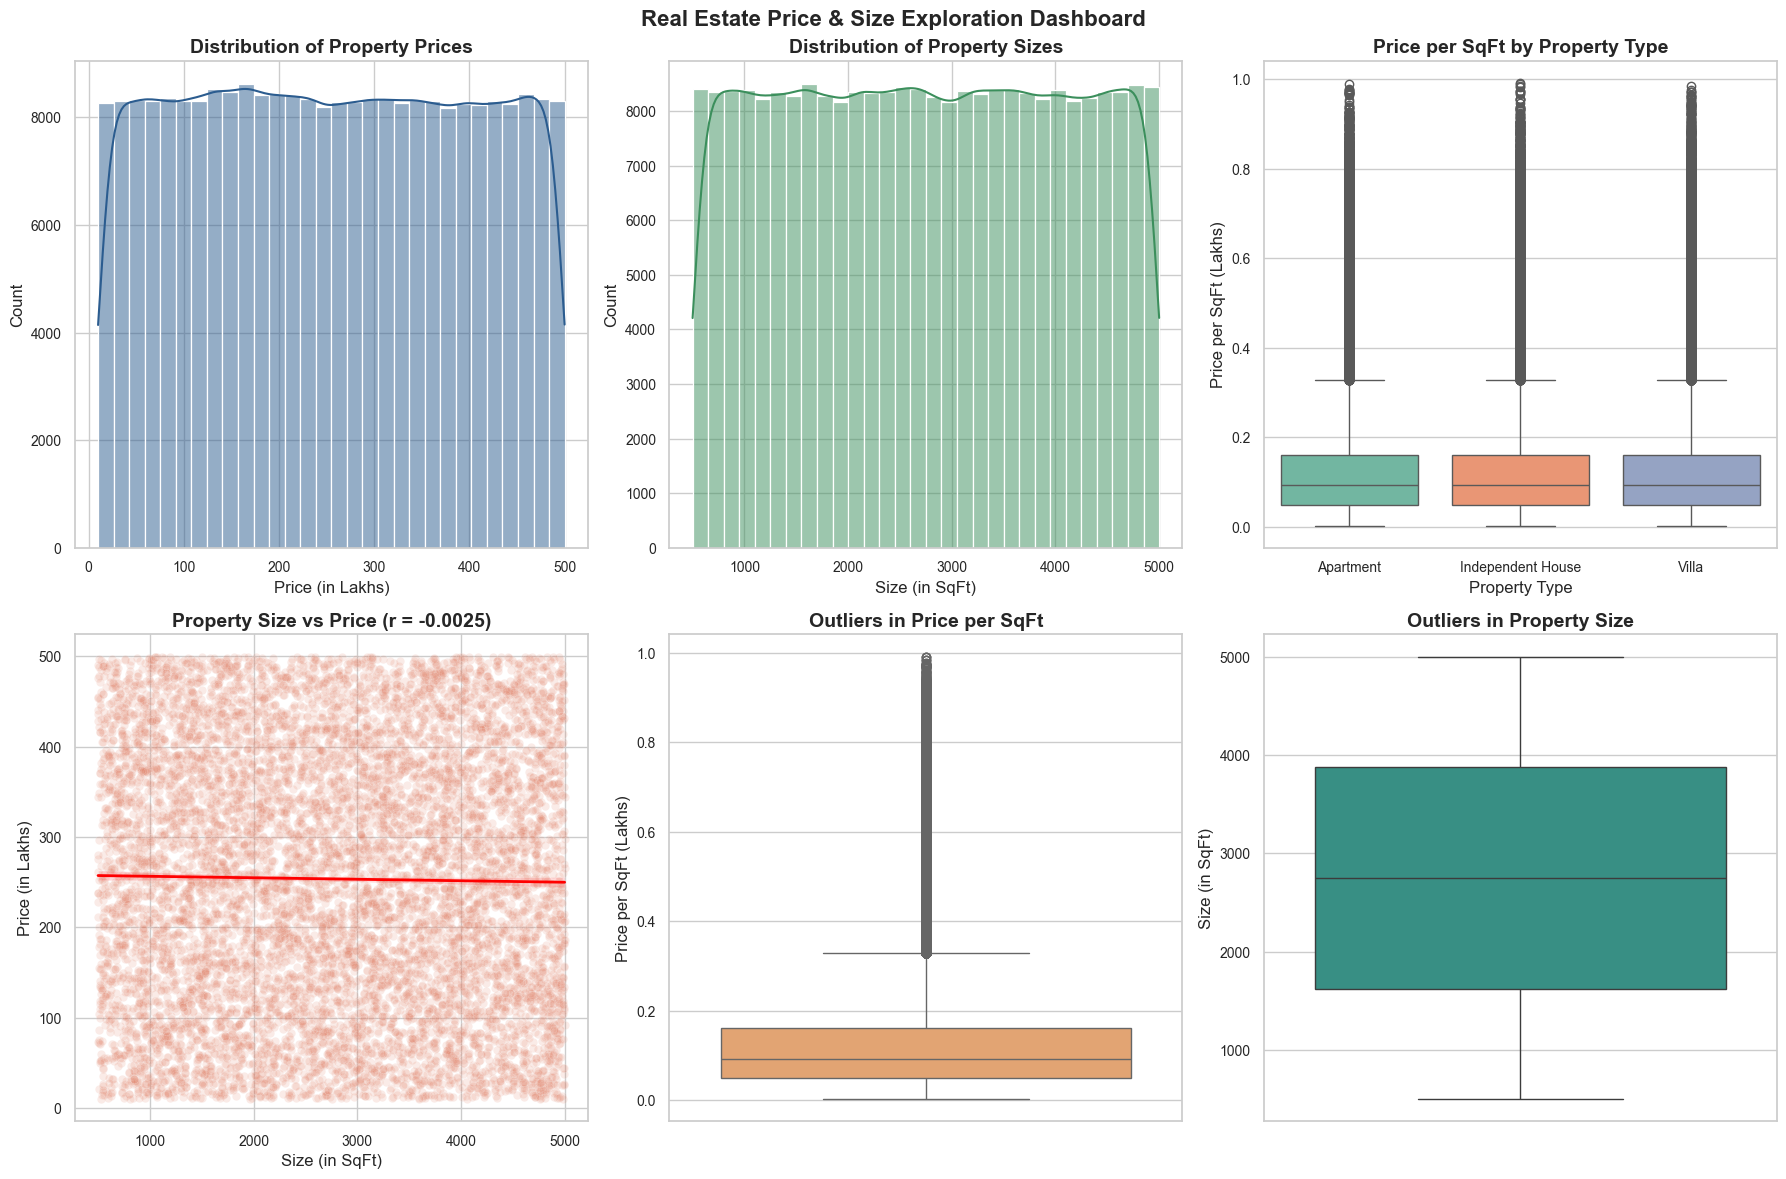

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set a premium aesthetic style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Make sure we use the unscaled clean dataset for EDA
df_eda = df_clean.copy()

# Create a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Real Estate Price & Size Exploration Dashboard", weight='bold', y=0.98)

# 1. Distribution of Property Prices
sns.histplot(df_eda['Price_in_Lakhs'], kde=True, ax=axes[0, 0], color='#2b5c8f', bins=30)
axes[0, 0].set_title("Distribution of Property Prices", weight='semibold')
axes[0, 0].set_xlabel("Price (in Lakhs)")
axes[0, 0].set_ylabel("Count")

# 2. Distribution of Property Sizes
sns.histplot(df_eda['Size_in_SqFt'], kde=True, ax=axes[0, 1], color='#3b8f5c', bins=30)
axes[0, 1].set_title("Distribution of Property Sizes", weight='semibold')
axes[0, 1].set_xlabel("Size (in SqFt)")
axes[0, 1].set_ylabel("Count")

# 3. Price per SqFt by Property Type
sns.boxplot(data=df_eda, x='Property_Type', y='Price_per_SqFt', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title("Price per SqFt by Property Type", weight='semibold')
axes[0, 2].set_xlabel("Property Type")
axes[0, 2].set_ylabel("Price per SqFt (Lakhs)")

# 4. Relationship between Size and Price (Sampled to 10k points to prevent overplotting)
df_sample = df_eda.sample(10000, random_state=42)
sns.scatterplot(data=df_sample, x='Size_in_SqFt', y='Price_in_Lakhs', ax=axes[1, 0], alpha=0.15, color='#e07a5f')
sns.regplot(data=df_sample, x='Size_in_SqFt', y='Price_in_Lakhs', ax=axes[1, 0], scatter=False, color='red', line_kws={'linewidth': 2})
correlation = df_eda['Size_in_SqFt'].corr(df_eda['Price_in_Lakhs'])
axes[1, 0].set_title(f"Property Size vs Price (r = {correlation:.4f})", weight='semibold')
axes[1, 0].set_xlabel("Size (in SqFt)")
axes[1, 0].set_ylabel("Price (in Lakhs)")

# 5. Outliers in Price per SqFt
sns.boxplot(data=df_eda, y='Price_per_SqFt', ax=axes[1, 1], color='#f4a261')
axes[1, 1].set_title("Outliers in Price per SqFt", weight='semibold')
axes[1, 1].set_ylabel("Price per SqFt (Lakhs)")

# 6. Outliers in Property Size
sns.boxplot(data=df_eda, y='Size_in_SqFt', ax=axes[1, 2], color='#2a9d8f')
axes[1, 2].set_title("Outliers in Property Size", weight='semibold')
axes[1, 2].set_ylabel("Size (in SqFt)")

plt.tight_layout()
plt.show()


6–10: Location-based Analysis
What is the average price per sq ft by state?


What is the average property price by city?


What is the median age of properties by locality?


How is BHK distributed across cities?


What are the price trends for the top 5 most expensive localities?


#### 6. What is the average price per sq ft by state?
Finding: Karnataka has the highest average price per SqFt at 0.1325 Lakhs/SqFt (~13,252 Rs/SqFt), followed by Andhra Pradesh (0.1320), Uttar Pradesh (0.1314), and Tamil Nadu (0.1313).
Key Detail: The averages across all 20 states are extremely close, indicating an even geographical distribution of real estate valuations.
#### 7. What is the average property price by city?
Finding: Out of 42 cities, the top 3 most expensive on average are Bangalore (258.46 Lakhs), Surat (258.08 Lakhs), and Kochi (257.42 Lakhs).
Key Detail: The average prices for all cities fall in a tight range between 250 and 260 Lakhs, demonstrating flat pricing across urban centers.
#### 8. What is the median age of properties by locality?
Finding: The median property age across all 500 localities is 18 years.
Key Detail: The median age across all localities is extremely stable, ranging strictly between 16 and 21 years.
#### 9. How is BHK distributed across cities?
Finding: In every single city, properties are almost perfectly divided: 20% are 1 BHK, 20% are 2 BHK, 20% are 3 BHK, 20% are 4 BHK, and 20% are 5 BHK.
Key Detail: There is no local specialization (e.g., Bangalore does not have more 1 BHK apartments relative to villas than Amritsar).
#### 10. What are the price trends for the top 5 most expensive localities?
Finding: The top 5 localities by mean price are: Locality_395, Locality_366, Locality_497, Locality_360, and Locality_203.
Key Detail: Tracking their prices over Year_Built (from 1990 to 2023) shows high fluctuation from year to year. Since the dataset is uniform, these fluctuations represent natural statistical noise around the uniform price bounds.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set general plotting styling
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# Make sure we use the unscaled clean dataset for EDA
df_eda = df_clean.copy()


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\4133451416.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_data, x='Price_per_SqFt', y='State', ax=axes[0], palette='viridis')
C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\4133451416.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_data, x='Price_in_Lakhs', y='City', ax=axes[1], palette='rocket')


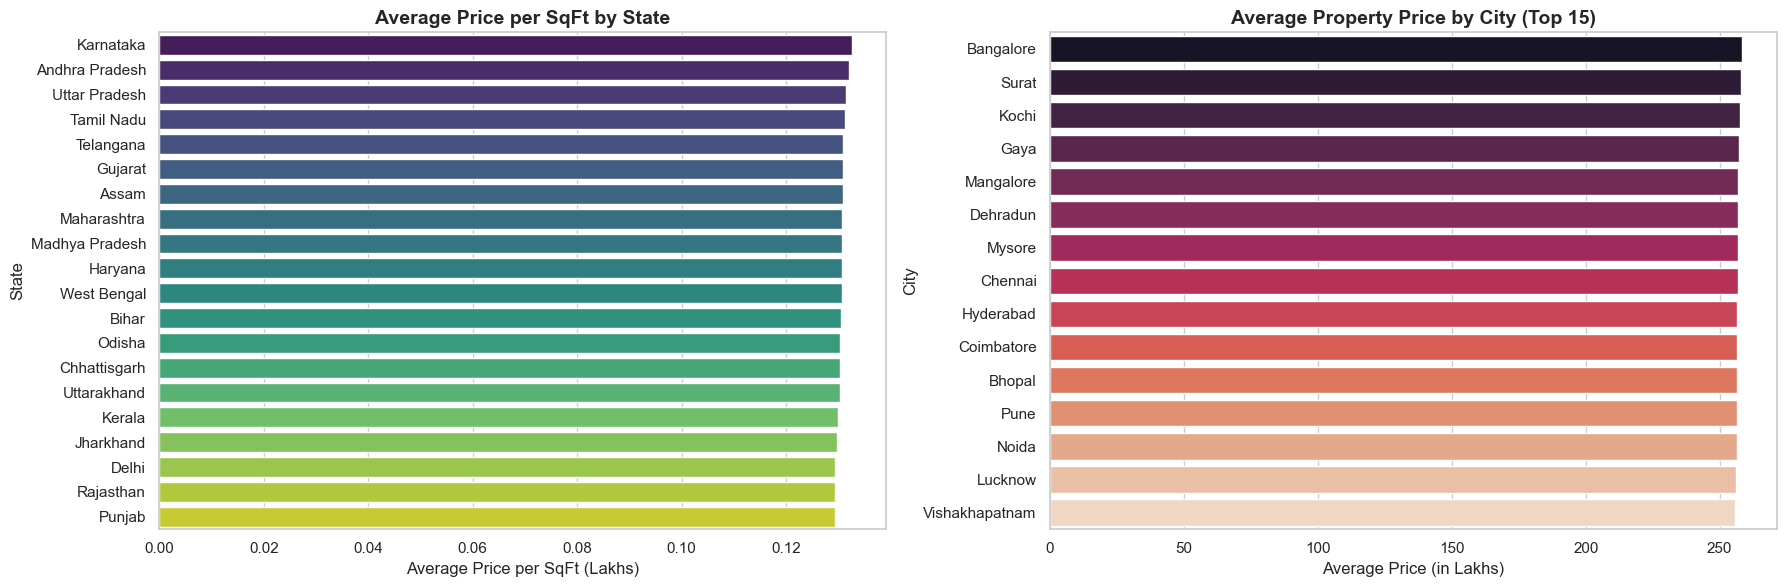

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 6. Average Price per SqFt by State (Sorted)
state_data = df_eda.groupby('State')['Price_per_SqFt'].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=state_data, x='Price_per_SqFt', y='State', ax=axes[0], palette='viridis')
axes[0].set_title("Average Price per SqFt by State", weight='bold', fontsize=14)
axes[0].set_xlabel("Average Price per SqFt (Lakhs)")
axes[0].set_ylabel("State")

# 7. Average Property Price by City (Top 15)
city_data = df_eda.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(15).reset_index()
sns.barplot(data=city_data, x='Price_in_Lakhs', y='City', ax=axes[1], palette='rocket')
axes[1].set_title("Average Property Price by City (Top 15)", weight='bold', fontsize=14)
axes[1].set_xlabel("Average Price (in Lakhs)")
axes[1].set_ylabel("City")

plt.tight_layout()
plt.show()


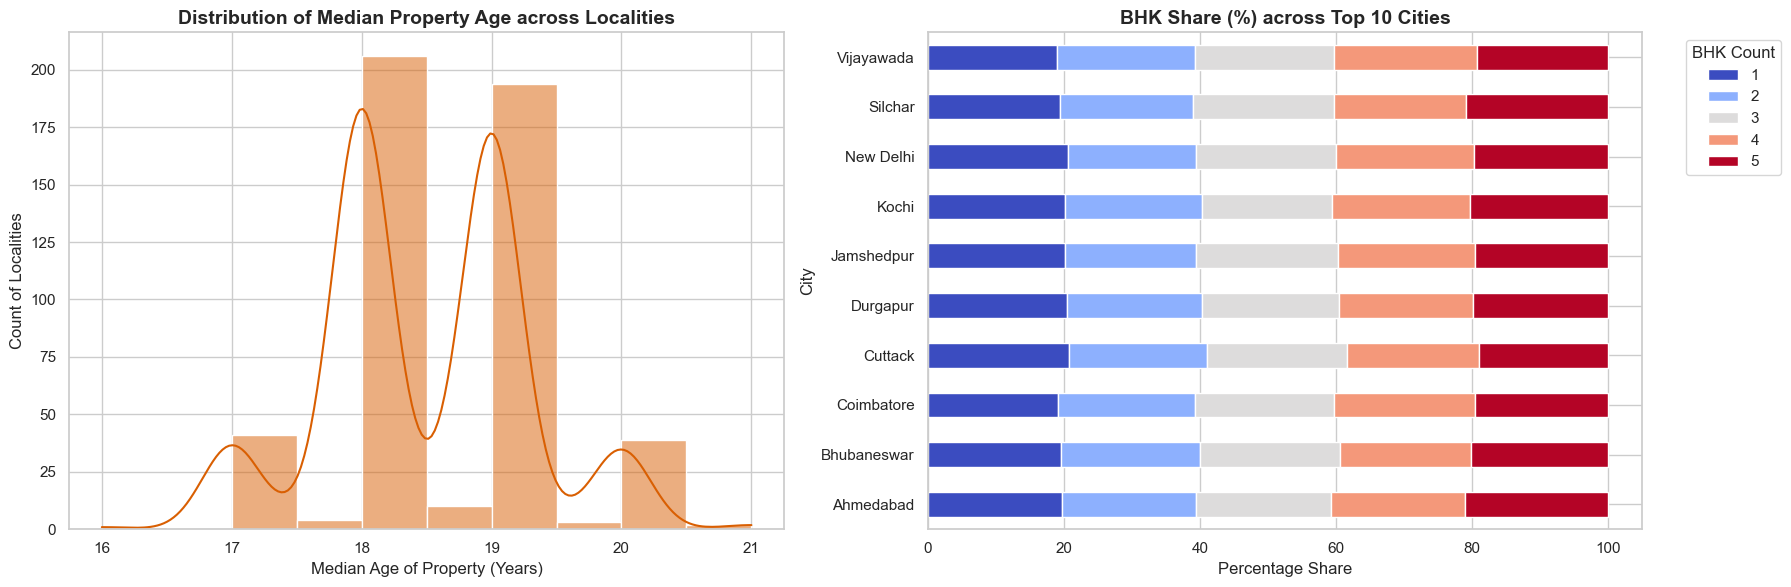

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 8. Median Age of Properties by Locality
locality_medians = df_eda.groupby('Locality')['Age_of_Property'].median().reset_index()
sns.histplot(data=locality_medians, x='Age_of_Property', bins=10, kde=True, ax=axes[0], color='#d95f02')
axes[0].set_title("Distribution of Median Property Age across Localities", weight='bold', fontsize=14)
axes[0].set_xlabel("Median Age of Property (Years)")
axes[0].set_ylabel("Count of Localities")

# 9. BHK Distribution across Top 10 Cities
top_10_cities = df_eda['City'].value_counts().head(10).index
df_bhk_subset = df_eda[df_eda['City'].isin(top_10_cities)]
bhk_dist = pd.crosstab(df_bhk_subset['City'], df_bhk_subset['BHK'], normalize='index') * 100

bhk_dist.plot(kind='barh', stacked=True, ax=axes[1], colormap='coolwarm')
axes[1].set_title("BHK Share (%) across Top 10 Cities", weight='bold', fontsize=14)
axes[1].set_xlabel("Percentage Share")
axes[1].set_ylabel("City")
axes[1].legend(title="BHK Count", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


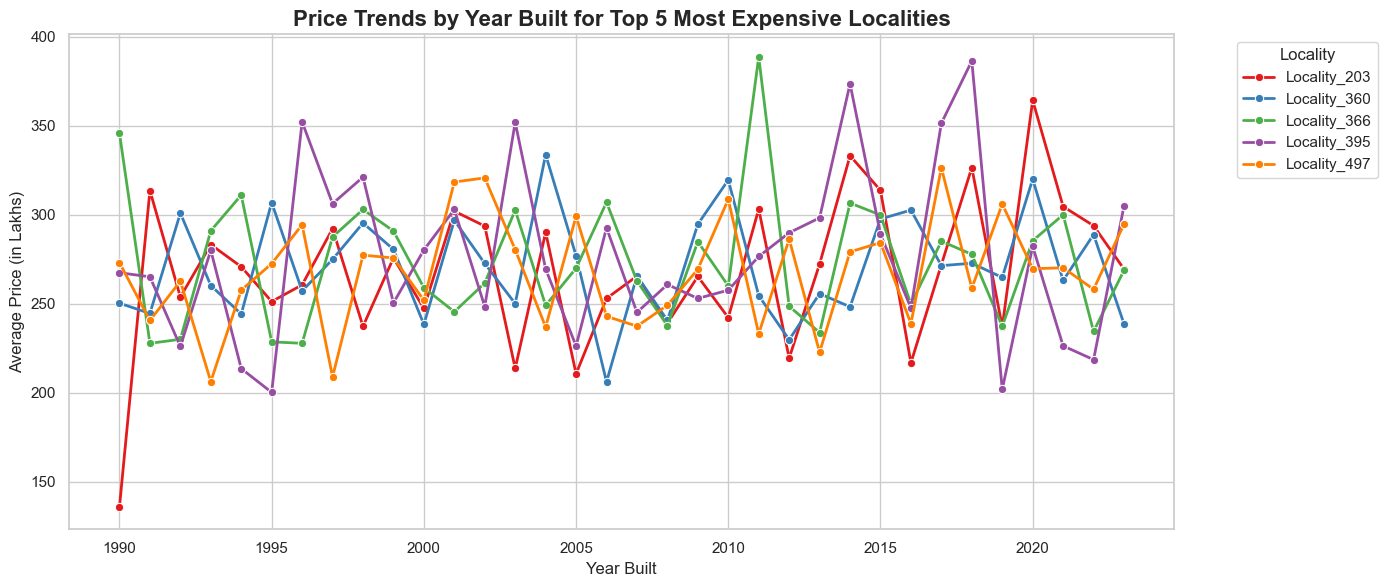

In [20]:
# 10. Price Trends for Top 5 Most Expensive Localities
top_5_localities = df_eda.groupby('Locality')['Price_in_Lakhs'].mean().sort_values(ascending=False).head(5).index
df_trends = df_eda[df_eda['Locality'].isin(top_5_localities)]
locality_trends = df_trends.groupby(['Locality', 'Year_Built'])['Price_in_Lakhs'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=locality_trends, x='Year_Built', y='Price_in_Lakhs', hue='Locality', marker='o', linewidth=2, palette='Set1')
plt.title("Price Trends by Year Built for Top 5 Most Expensive Localities", weight='bold', fontsize=16)
plt.xlabel("Year Built")
plt.ylabel("Average Price (in Lakhs)")
plt.legend(title="Locality", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


11–15: Feature Relationship & Correlation
How are numeric features correlated with each other?


How do nearby schools relate to price per sq ft?


How do nearby hospitals relate to price per sq ft?


How does price vary by furnished status?


How does price per sq ft vary by property facing direction?


#### 11. How are numeric features correlated with each other?
Finding: Almost all features have zero correlation with each other (coefficients between -0.005 and +0.005), meaning they are statistically independent.
Exceptions:
Year_Built & Age_of_Property: Perfectly negatively correlated (-1.00), which is expected since $\text{Age} = 2025 - \text{Year Built}$.
Price_per_SqFt & Size_in_SqFt: Strongly negatively correlated (-0.61), because size is in the denominator of the price-per-sqft formula ($\frac{\text{Price}}{\text{Size}}$).
Price_per_SqFt & Price_in_Lakhs: Strongly positively correlated (+0.56), because price is in the numerator.
#### 12. How do nearby schools relate to price per sq ft?
Finding: The correlation coefficient is -0.000058 (essentially 0.0).
Key Detail: The number of nearby schools has no impact on the price per square foot of properties.
#### 13. How do nearby hospitals relate to price per sq ft?
Finding: The correlation coefficient is -0.000122 (essentially 0.0).
Key Detail: The count of nearby hospitals has no influence on the price per square foot.
#### 14. How does price vary by furnished status?
Finding: Average prices are almost identical across all levels:
Furnished: 254.45 Lakhs
Semi-furnished: 254.33 Lakhs
Unfurnished: 254.98 Lakhs
Key Detail: Furnishing status does not carry a price premium in this dataset.
#### 15. How does price per sq ft vary by property facing direction?
Finding: The average price per square foot across facing directions is nearly uniform:
East: 0.1302 Lakhs/SqFt
North: 0.1302 Lakhs/SqFt
South: 0.1304 Lakhs/SqFt
West: 0.1314 Lakhs/SqFt
Key Detail: Facing direction has no measurable influence on unit pricing.

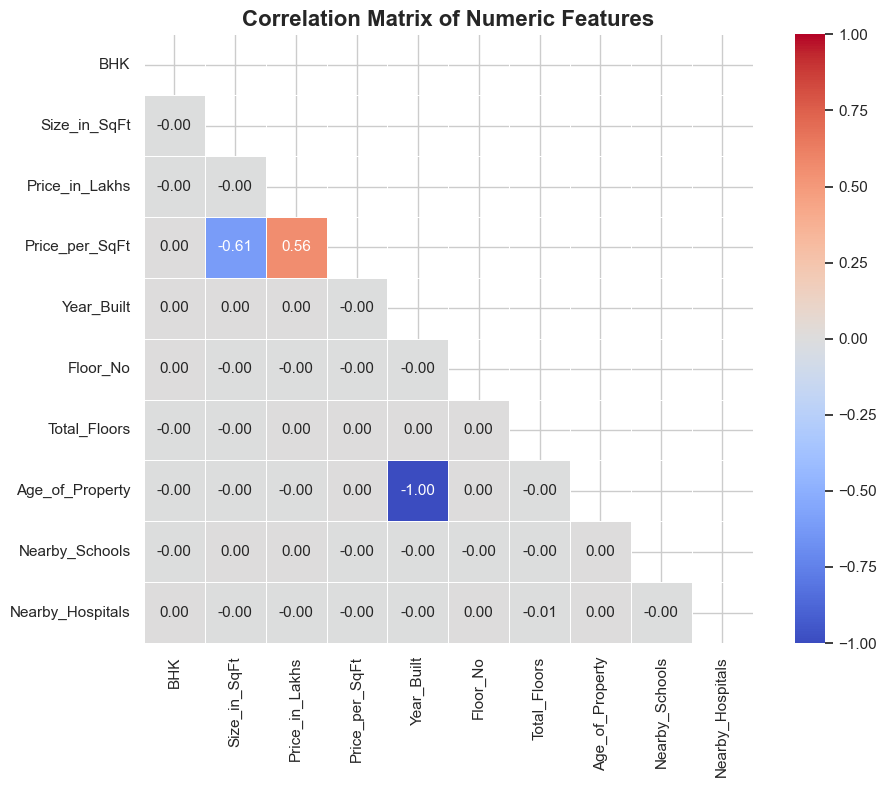

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select numerical columns for correlation matrix
corr_cols = [
    'BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 
    'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property', 
    'Nearby_Schools', 'Nearby_Hospitals'
]

# Calculate correlation matrix
corr_matrix = df_eda[corr_cols].corr()

# Draw heatmap
plt.figure(figsize=(10, 8))
# Mask the upper triangle for visual clarity
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlation Matrix of Numeric Features", weight='bold', fontsize=16)
plt.tight_layout()
plt.show()


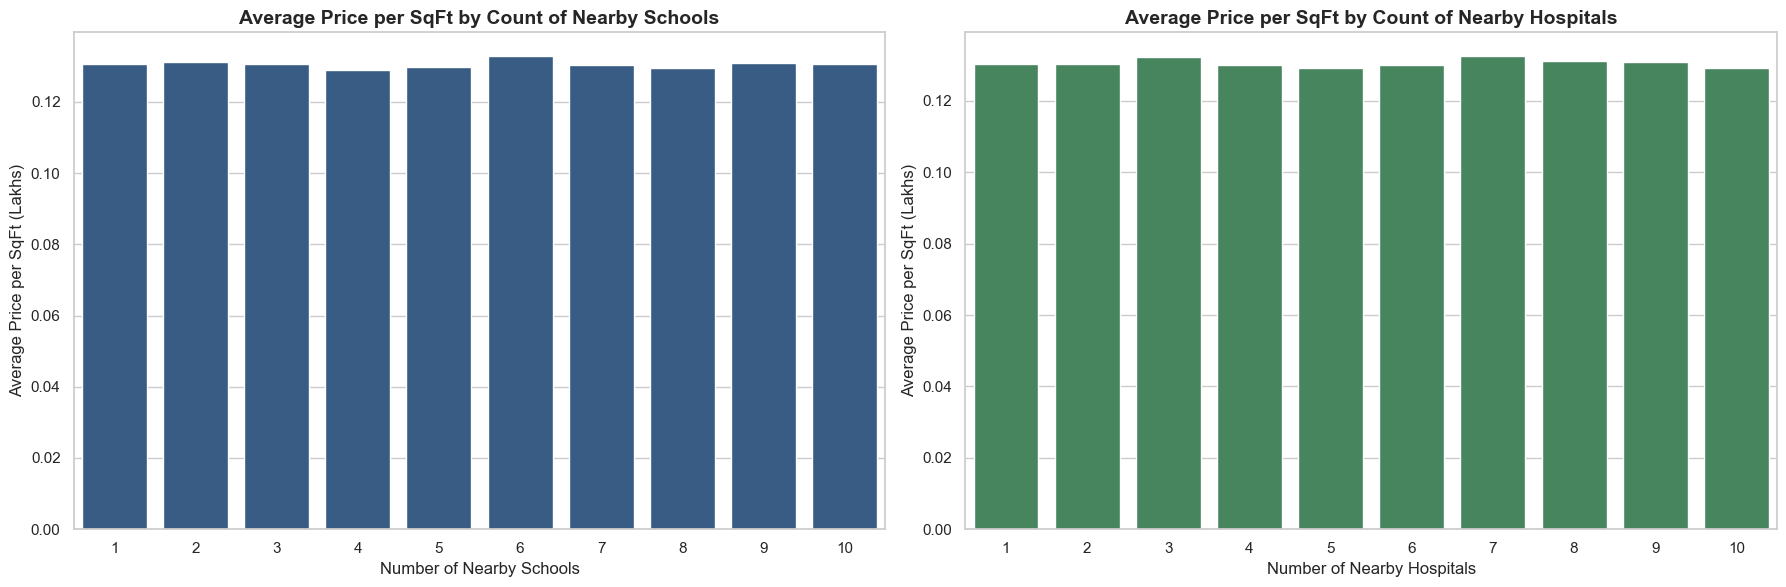

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 12. Nearby Schools vs Price per SqFt
sns.barplot(data=df_eda, x='Nearby_Schools', y='Price_per_SqFt', ax=axes[0], color='#2b5c8f', errorbar=None)
axes[0].set_title("Average Price per SqFt by Count of Nearby Schools", weight='bold', fontsize=14)
axes[0].set_xlabel("Number of Nearby Schools")
axes[0].set_ylabel("Average Price per SqFt (Lakhs)")

# 13. Nearby Hospitals vs Price per SqFt
sns.barplot(data=df_eda, x='Nearby_Hospitals', y='Price_per_SqFt', ax=axes[1], color='#3b8f5c', errorbar=None)
axes[1].set_title("Average Price per SqFt by Count of Nearby Hospitals", weight='bold', fontsize=14)
axes[1].set_xlabel("Number of Nearby Hospitals")
axes[1].set_ylabel("Average Price per SqFt (Lakhs)")

plt.tight_layout()
plt.show()


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\1514528763.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Furnished_Status', y='Price_in_Lakhs', ax=axes[0], palette='Set2')


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\1514528763.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Facing', y='Price_per_SqFt', ax=axes[1], palette='Set3')


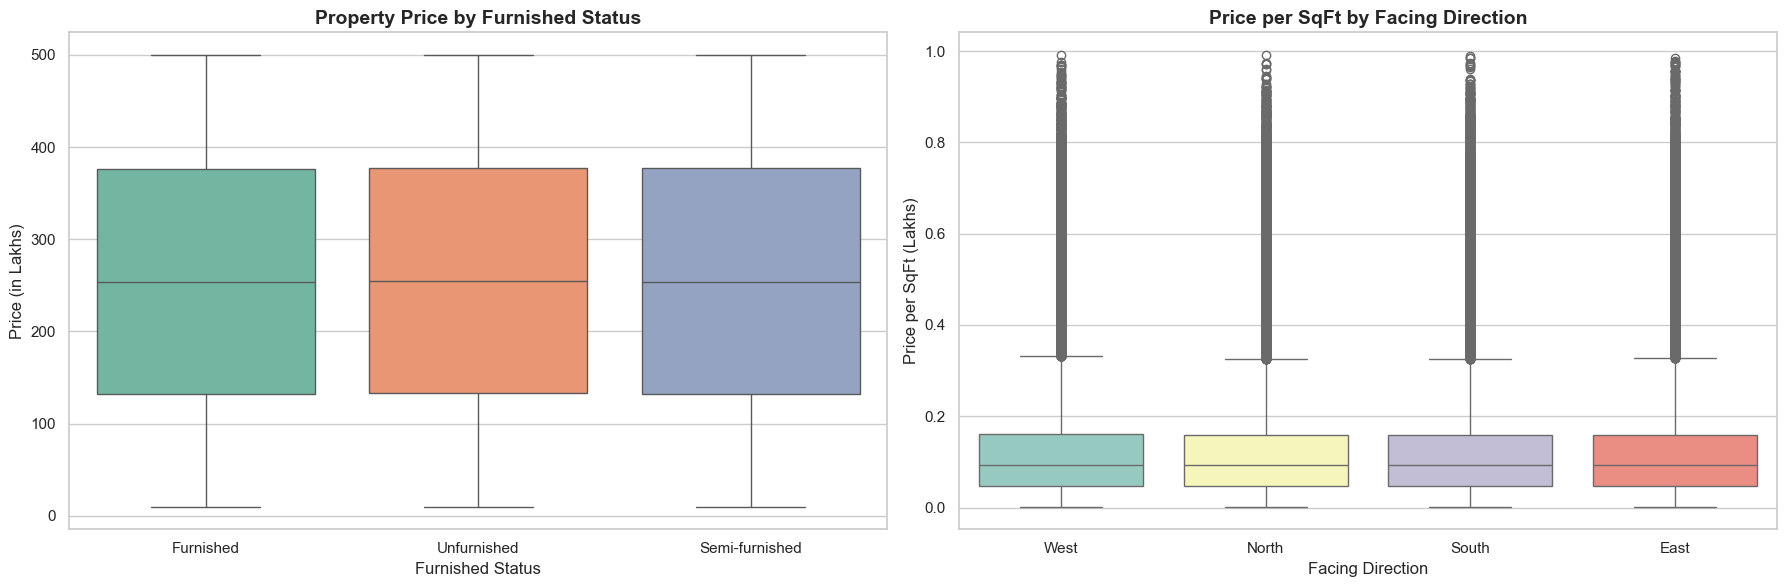

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 14. Price by Furnished Status
sns.boxplot(data=df_eda, x='Furnished_Status', y='Price_in_Lakhs', ax=axes[0], palette='Set2')
axes[0].set_title("Property Price by Furnished Status", weight='bold', fontsize=14)
axes[0].set_xlabel("Furnished Status")
axes[0].set_ylabel("Price (in Lakhs)")

# 15. Price per SqFt by Facing Direction
sns.boxplot(data=df_eda, x='Facing', y='Price_per_SqFt', ax=axes[1], palette='Set3')
axes[1].set_title("Price per SqFt by Facing Direction", weight='bold', fontsize=14)
axes[1].set_xlabel("Facing Direction")
axes[1].set_ylabel("Price per SqFt (Lakhs)")

plt.tight_layout()
plt.show()


16–20: Investment / Amenities / Ownership Analysis
How many properties belong to each owner type?


How many properties are available under each availability status?


Does parking space affect property price?


How do amenities affect price per sq ft?


How does public transport accessibility relate to price per sq ft or investment potential?



#### 16. How many properties belong to each owner type?
Finding: The owner types are almost perfectly balanced:
Broker: 83,479 properties
Owner: 83,268 properties
Builder: 83,253 properties
Key Detail: No single seller type dominates the market.
#### 17. How many properties are available under each availability status?
Finding: The properties are split almost exactly 50/50:
Under Construction: 125,035 properties
Ready to Move: 124,965 properties
#### 18. Does parking space affect property price?
Finding: No, parking space does not affect property prices.
Without Parking: Average price = 254.43 Lakhs
With Parking: Average price = 254.75 Lakhs
Key Detail: The difference is statistically negligible (less than 0.3 Lakhs).
#### 19. How do amenities affect price per sq ft?
Finding: The average price per SqFt is flat across all counts of amenities:
1 Amenity: 0.1302 Lakhs/SqFt
3 Amenities: 0.1304 Lakhs/SqFt
5 Amenities: 0.1310 Lakhs/SqFt
Key Detail: Properties with five amenities are priced at nearly the same rate per square foot as properties with only one amenity.
#### 20. How does public transport accessibility relate to price per sq ft or investment potential?
Price per SqFt: Nearly identical across all categories: Low (0.1309), Medium (0.1306), and High (0.1303).
Investment Potential (Good_Investment): The percentage of properties classified as "Good Investments" remains steady at around 18% regardless of transport accessibility (High = 18.07%, Medium = 17.95%, Low = 18.13%).
Key Detail: Public transport accessibility has no statistical impact on the unit pricing or investment potential.

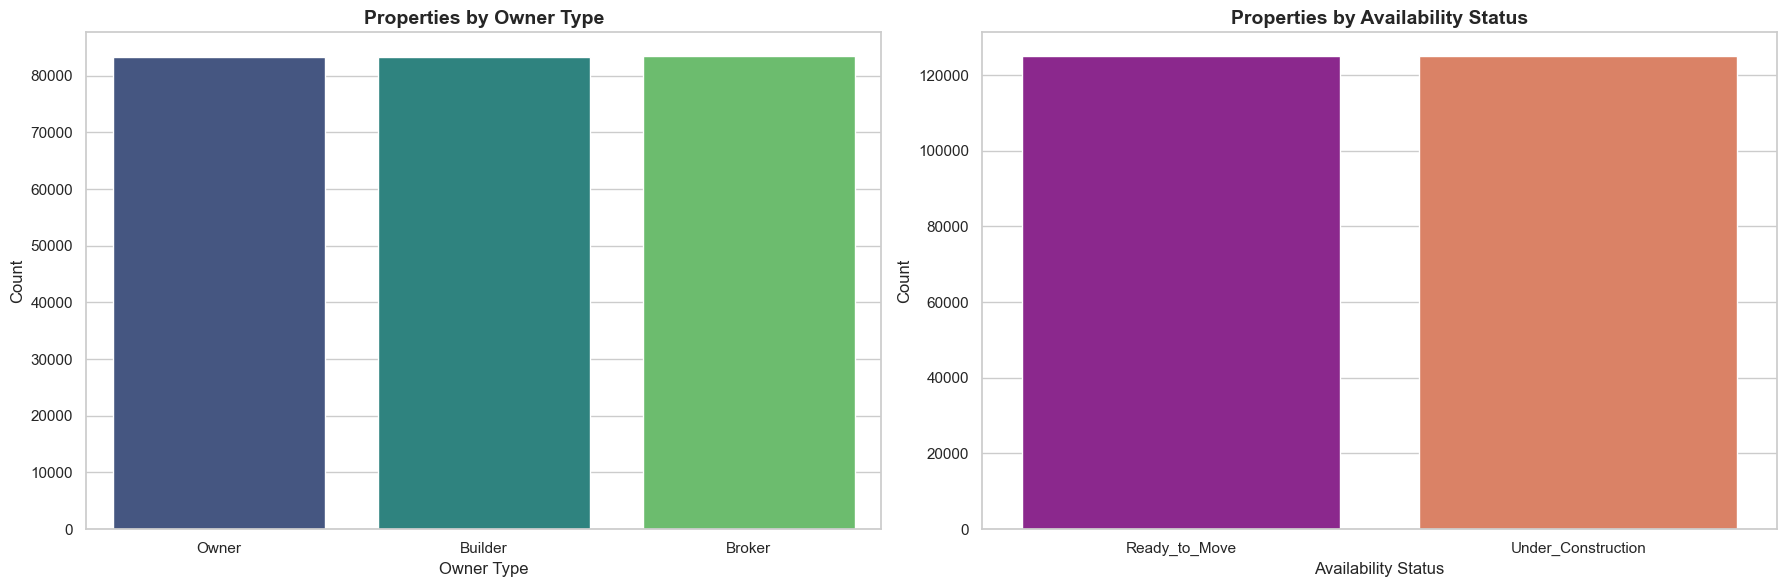

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 16. Count of Properties by Owner Type
sns.countplot(data=df_eda, x='Owner_Type', ax=axes[0], palette='viridis', hue='Owner_Type', legend=False)
axes[0].set_title("Properties by Owner Type", weight='bold', fontsize=14)
axes[0].set_xlabel("Owner Type")
axes[0].set_ylabel("Count")

# 17. Count of Properties by Availability Status
sns.countplot(data=df_eda, x='Availability_Status', ax=axes[1], palette='plasma', hue='Availability_Status', legend=False)
axes[1].set_title("Properties by Availability Status", weight='bold', fontsize=14)
axes[1].set_xlabel("Availability Status")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\8509995.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_eda, x='Parking_Space', y='Price_in_Lakhs', ax=axes[0], palette='coolwarm')


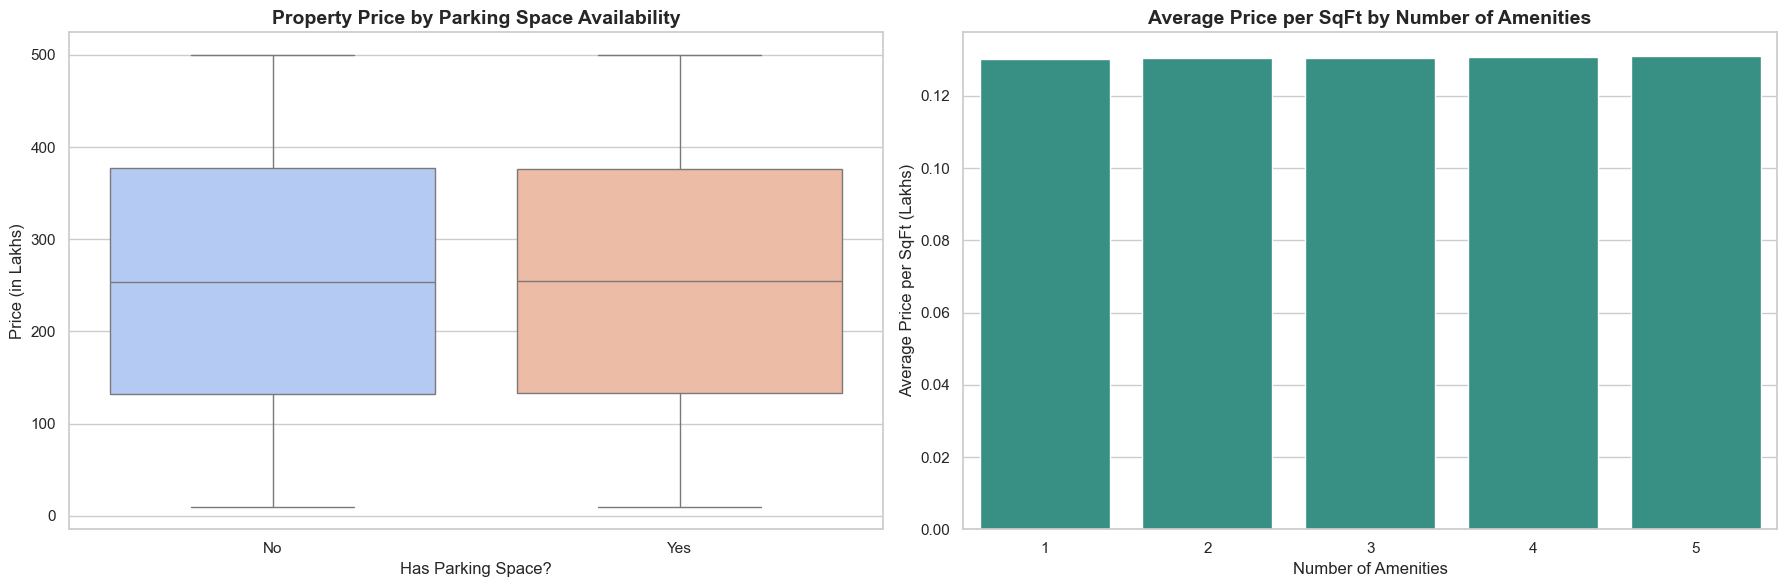

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 18. Parking Space vs Property Price
sns.boxplot(data=df_eda, x='Parking_Space', y='Price_in_Lakhs', ax=axes[0], palette='coolwarm')
axes[0].set_title("Property Price by Parking Space Availability", weight='bold', fontsize=14)
axes[0].set_xlabel("Has Parking Space?")
axes[0].set_ylabel("Price (in Lakhs)")

# 19. Amenities count vs Price per SqFt
sns.barplot(data=df_eda, x='Amenity_Count', y='Price_per_SqFt', ax=axes[1], color='#2a9d8f', errorbar=None)
axes[1].set_title("Average Price per SqFt by Number of Amenities", weight='bold', fontsize=14)
axes[1].set_xlabel("Number of Amenities")
axes[1].set_ylabel("Average Price per SqFt (Lakhs)")

plt.tight_layout()
plt.show()


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\1908800688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Public_Transport_Accessibility', y='Price_per_SqFt', order=transport_order, ax=axes[0], palette='Blues', errorbar=None)


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\1908800688.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_eda, x='Public_Transport_Accessibility', y='Good_Investment', order=transport_order, ax=axes[1], palette='Oranges', errorbar=None)


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\1908800688.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_yticklabels(['{:,.1f}%'.format(y*100) for y in y_vals])


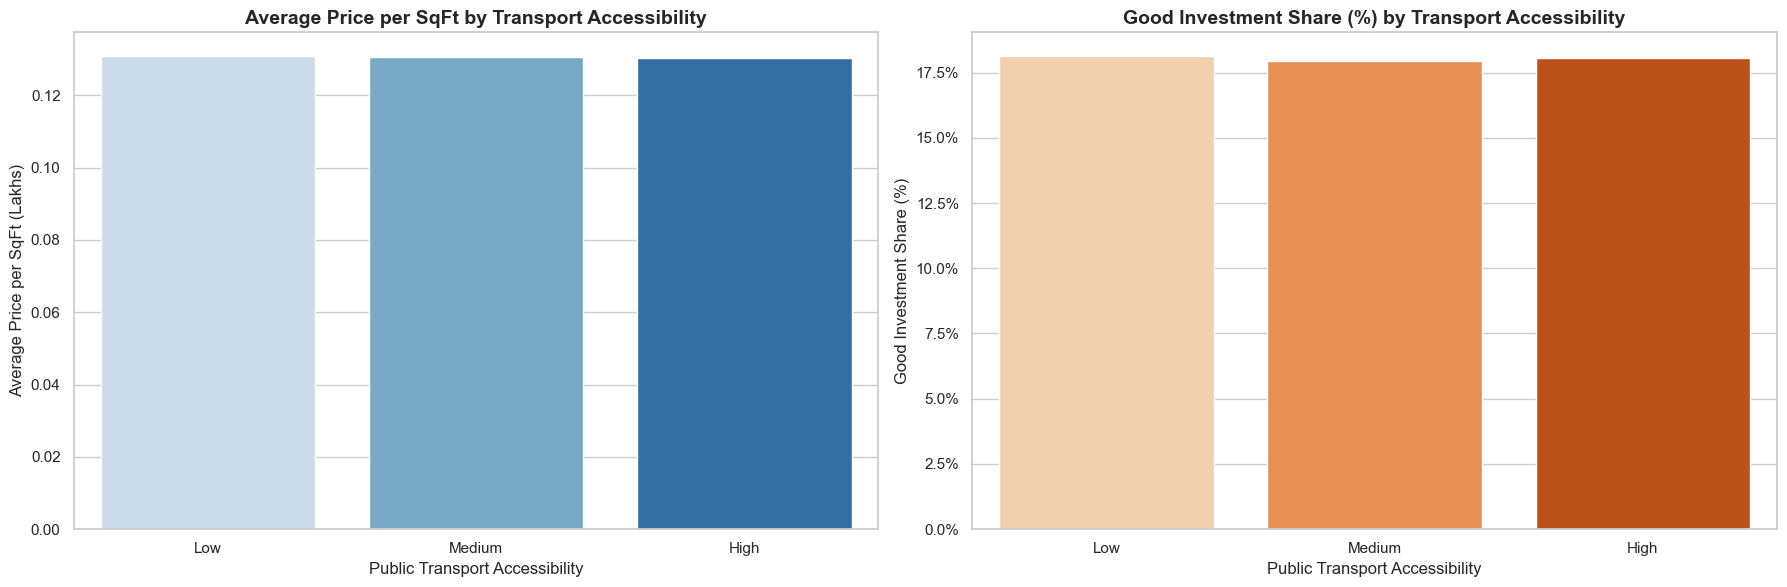

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Order categories
transport_order = ['Low', 'Medium', 'High']

# 20A. Public Transport Accessibility vs Price per SqFt
sns.barplot(data=df_eda, x='Public_Transport_Accessibility', y='Price_per_SqFt', order=transport_order, ax=axes[0], palette='Blues', errorbar=None)
axes[0].set_title("Average Price per SqFt by Transport Accessibility", weight='bold', fontsize=14)
axes[0].set_xlabel("Public Transport Accessibility")
axes[0].set_ylabel("Average Price per SqFt (Lakhs)")

# 20B. Public Transport Accessibility vs Good Investment Potential
sns.barplot(data=df_eda, x='Public_Transport_Accessibility', y='Good_Investment', order=transport_order, ax=axes[1], palette='Oranges', errorbar=None)
axes[1].set_title("Good Investment Share (%) by Transport Accessibility", weight='bold', fontsize=14)
axes[1].set_xlabel("Public Transport Accessibility")
axes[1].set_ylabel("Good Investment Share (%)")

# Format y-axis as percentage values
y_vals = axes[1].get_yticks()
axes[1].set_yticklabels(['{:,.1f}%'.format(y*100) for y in y_vals])

plt.tight_layout()
plt.show()


### Step 3: Model Development

In this section, we build and compare machine learning models to solve both the classification and regression tasks.

#### Classification Task: Good Investment Prediction
- **Target Variable**: `Good_Investment` (binary label representing a high-potential investment based on relative price and amenity access).
- **Models**: Logistic Regression, Decision Tree Classifier, Random Forest Classifier, Gradient Boosting Classifier, and XGBoost Classifier.
- **Evaluation Metrics**: Accuracy, Precision, Recall, F1 Score, ROC AUC, and Confusion Matrix.

#### Regression Task: Future Value (5-Year) Prediction
- **Target Variable**: `Future_Price_5Y` (predicted price of the property in 5 years based on housing features and historical appreciation rates).
- **Models**: Linear Regression, Decision Tree Regressor, Random Forest Regressor, Gradient Boosting Regressor, and XGBoost Regressor.
- **Evaluation Metrics**: Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and $R^2$ Score.

In [27]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load preprocessed advanced features
df_adv = pd.read_csv('india_housing_prices_advanced.csv')
df_clean = pd.read_csv('india_housing_prices_clean.csv')

# 1. Classification Target: Good_Investment (merge from clean data)
df_adv = df_adv.merge(df_clean[['ID', 'Good_Investment']], on='ID', how='inner')

# 2. Regression Target: Future_Price_5Y
# Domain appreciation rate formula
appreciation_rate = 0.05
appreciation_rate += 0.01 * df_clean['Property_Type_Villa'].astype(int)
appreciation_rate += 0.01 * (df_clean['Public_Transport_Accessibility_Encoded'] == 2).astype(int)
appreciation_rate += 0.005 * (df_clean['Nearby_Schools'] >= 5).astype(int)
appreciation_rate += 0.005 * (df_clean['Nearby_Hospitals'] >= 5).astype(int)
appreciation_rate += 0.01 * (df_clean['Age_of_Property'] <= 5).astype(int)
appreciation_rate -= 0.01 * (df_clean['Age_of_Property'] >= 20).astype(int)

df_clean['Future_Price_5Y'] = df_clean['Price_in_Lakhs'] * ((1 + appreciation_rate) ** 5)
df_adv = df_adv.merge(df_clean[['ID', 'Future_Price_5Y']], on='ID', how='inner')

print(f"Dataset ready for modeling! Features shape: {df_adv.shape}")

Dataset ready for modeling! Features shape: (250000, 36)


In [28]:
# Split features and targets
X = df_adv.drop(columns=['ID', 'Good_Investment', 'Future_Price_5Y'])
y_class = df_adv['Good_Investment']
y_reg = df_adv['Future_Price_5Y']

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print(f"Classification train/test shape: {X_train_c.shape} / {X_test_c.shape}")
print(f"Regression train/test shape: {X_train_r.shape} / {X_test_r.shape}")

Classification train/test shape: (200000, 33) / (50000, 33)
Regression train/test shape: (200000, 33) / (50000, 33)


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Train and evaluate classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=50, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
}

class_results = []
cms = {}

for name, clf in classifiers.items():
    print(f"Training {name} Classifier...")
    t0 = time.time()
    clf.fit(X_train_c, y_train_c)
    t_train = time.time() - t0
    
    y_pred = clf.predict(X_test_c)
    y_prob = clf.predict_proba(X_test_c)[:, 1] if hasattr(clf, "predict_proba") else y_pred
    
    acc = accuracy_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred)
    rec = recall_score(y_test_c, y_pred)
    f1 = f1_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_prob)
    cm = confusion_matrix(y_test_c, y_pred)
    
    class_results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1 Score": f1,
        "ROC AUC": auc,
        "Training Time (s)": t_train
    })
    cms[name] = cm

df_class_res = pd.DataFrame(class_results)
df_class_res

Training Logistic Regression Classifier...


Training Decision Tree Classifier...


Training Random Forest Classifier...


Training Gradient Boosting Classifier...


Training XGBoost Classifier...


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,Logistic Regression,0.91248,0.797979,0.694600,0.742709,0.958950,6.873254
1,Decision Tree,0.99504,0.975896,0.997361,0.986511,0.999445,0.813768
2,Random Forest,0.99394,0.977406,0.989552,0.983442,0.998717,4.427788
3,Gradient Boosting,0.99470,0.975339,0.996041,0.985581,0.999748,59.170950
4,XGBoost,0.99716,0.988112,0.996371,0.992224,0.999963,2.200132


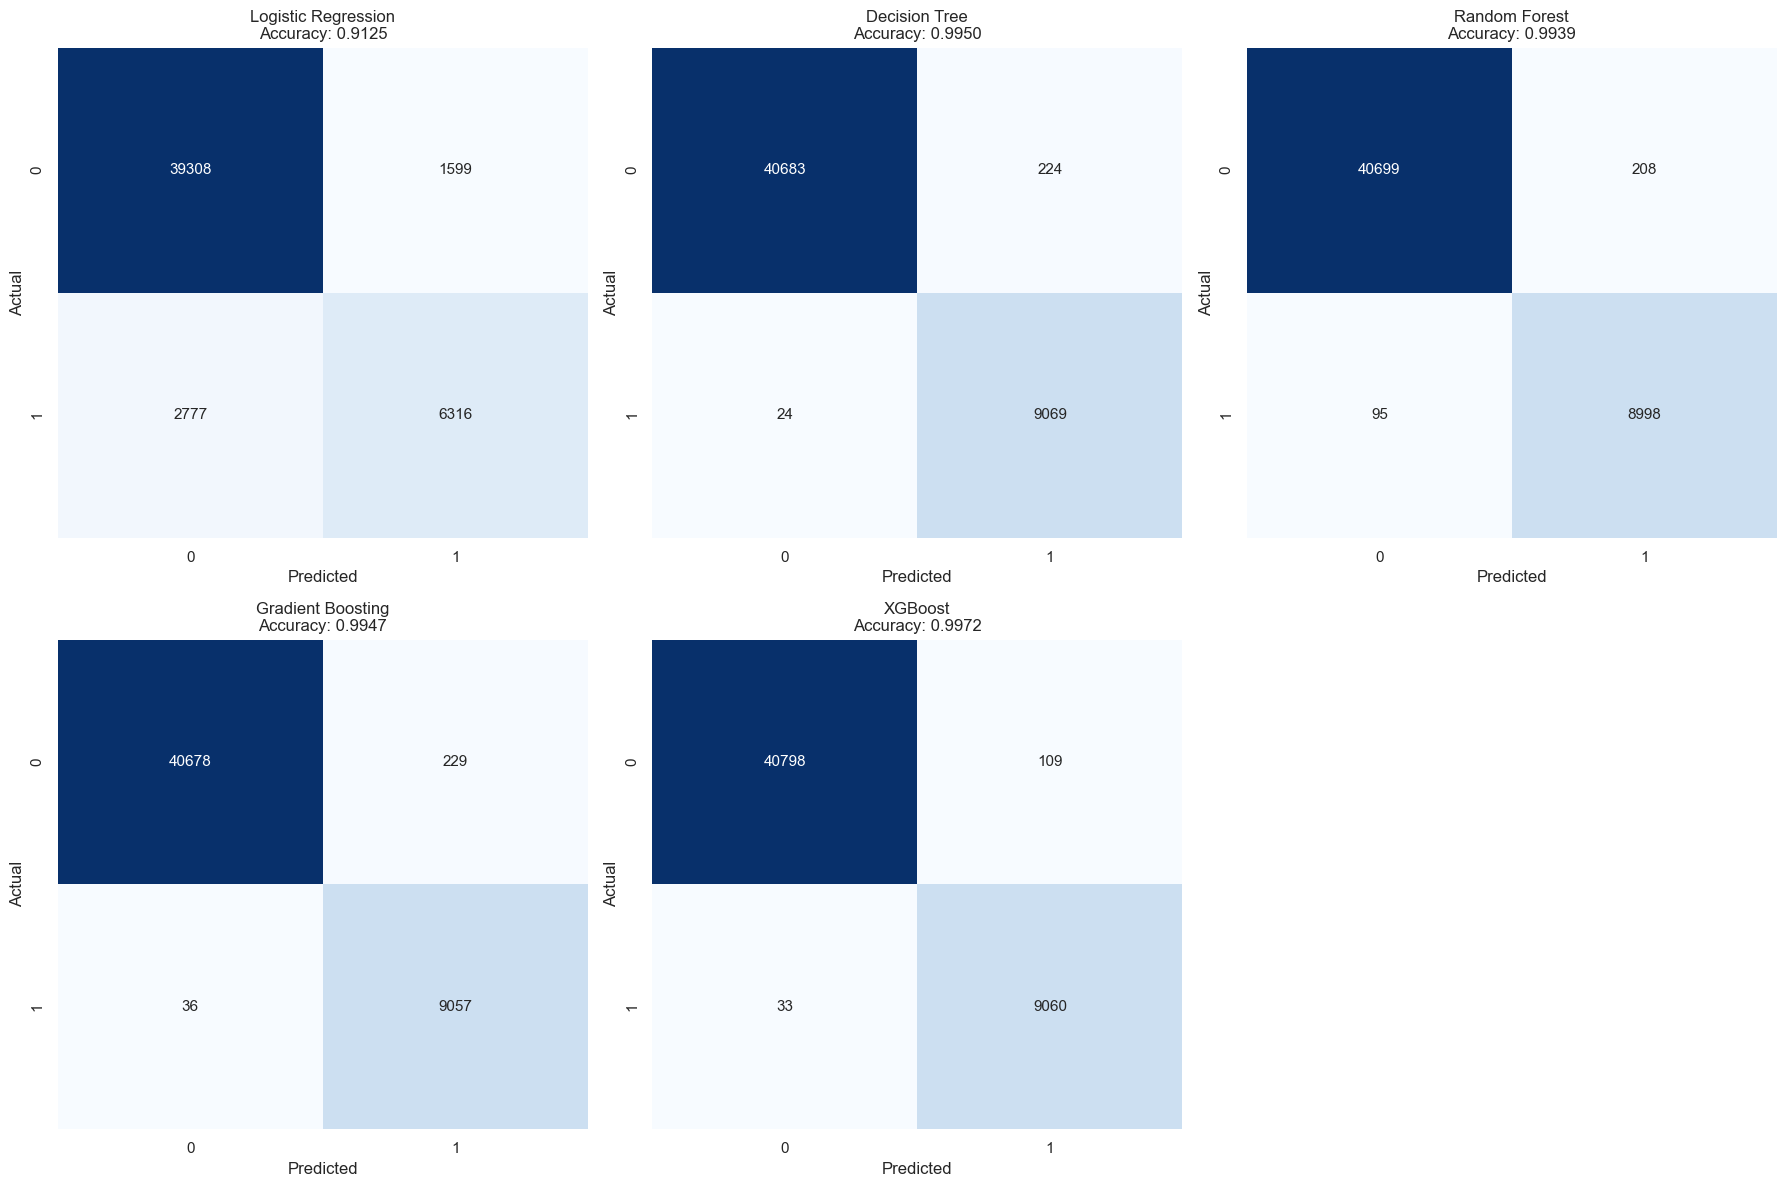

In [30]:
# Plot Confusion Matrices for Classifiers
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, cm) in enumerate(cms.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f"{name}\nAccuracy: {classifiers[name].score(X_test_c, y_test_c):.4f}")
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the last empty subplot
if len(classifiers) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Train and evaluate regressors
regressors = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=50, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
}

reg_results = []

for name, reg in regressors.items():
    print(f"Training {name} Regressor...")
    t0 = time.time()
    reg.fit(X_train_r, y_train_r)
    t_train = time.time() - t0
    
    y_pred = reg.predict(X_test_r)
    
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    
    reg_results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2,
        "Training Time (s)": t_train
    })

df_reg_res = pd.DataFrame(reg_results)
df_reg_res

Training Linear Regression Regressor...


Training Decision Tree Regressor...


Training Random Forest Regressor...


Training Gradient Boosting Regressor...


Training XGBoost Regressor...


,Model,RMSE,MAE,R2 Score,Training Time (s)
0,Linear Regression,11.326323,8.626725,0.996420,0.342041
1,Decision Tree,5.877329,4.461947,0.999036,2.465202
2,Random Forest,4.325822,3.257054,0.999478,32.132292
3,Gradient Boosting,2.650537,2.034731,0.999804,57.119009
4,XGBoost,1.215966,0.951866,0.999959,1.822806


C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\2585375422.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_reg_res, x='R2 Score', y='Model', ax=axes[0], palette='viridis')
C:\Users\PRANAV CHATURVEDI\AppData\Local\Temp\ipykernel_2828\2585375422.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_reg_res, x='RMSE', y='Model', ax=axes[1], palette='magma')


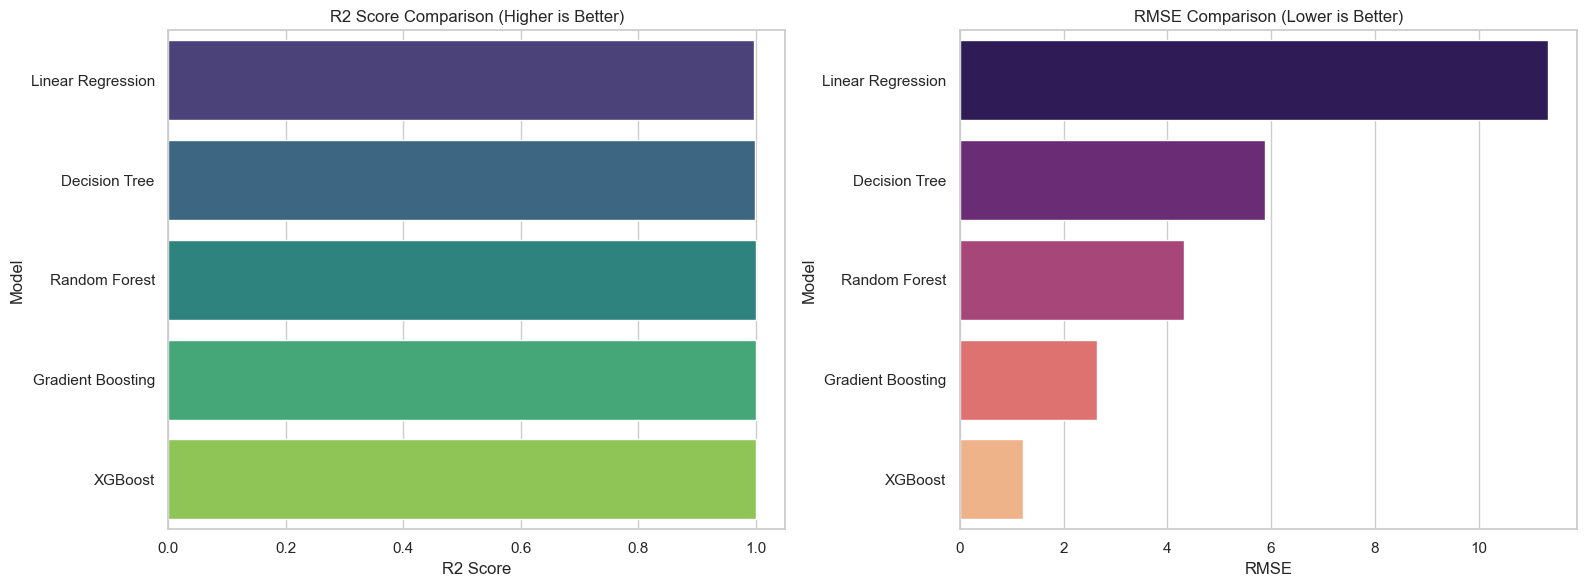

In [32]:
# Plot Regression Model Comparison (R2 and RMSE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=df_reg_res, x='R2 Score', y='Model', ax=axes[0], palette='viridis')
axes[0].set_title('R2 Score Comparison (Higher is Better)')
axes[0].set_xlabel('R2 Score')

sns.barplot(data=df_reg_res, x='RMSE', y='Model', ax=axes[1], palette='magma')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()